# Sprint 9: Digest Scoring Baseline Analysis

Evaluating cairn's three-layer scoring pipeline against human review decisions.

**Scoring layers:**
- **LLM Relevance** (0-1): Qwen 32B rates article relevance to user interests
- **Embedding Similarity** (0-1): Cosine similarity against SCMS project memories
- **Cross-Encoder** (~-10 to +10): cairn-rank relevance score (added Sprint 8 — older items may lack this)

**Human judgment:** Approved (`status='completed'`) vs Rejected (`status='cancelled'`)

In [1]:
import sys
from pathlib import Path

# Find project root by looking for .env (works whether Jupyter launched
# from project root, notebooks/, or anywhere else)
_cwd = Path.cwd()
for _candidate in [_cwd, _cwd.parent, _cwd.parent.parent]:
    if (_candidate / ".env").exists():
        project_root = _candidate
        break
else:
    raise FileNotFoundError(
        f"Cannot find .env (searched up from {_cwd}). "
        "Launch Jupyter from the cairn project root."
    )

# Load env vars BEFORE any cairn imports — pydantic-settings reads
# os.environ at module import time via `settings = Settings()`
from dotenv import load_dotenv
loaded = load_dotenv(project_root / ".env", override=True)
print(f"Project root: {project_root}")
print(f".env loaded: {loaded}")

sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from agent.evaluation import load_reviewed_items

# Load labeled data from Supabase
items = load_reviewed_items(limit=1000)
print(f"Loaded {len(items)} reviewed items")

# Convert to DataFrame
df = pd.DataFrame([
    {
        "title": i.title,
        "source": i.source_name,
        "relevance": i.relevance_score,
        "embedding": i.embedding_score,
        "cross_encoder": i.cross_encoder_score,
        "approved": i.approved,
        "created_at": pd.to_datetime(i.created_at),
    }
    for i in items
])

df.head()

Project root: /Users/rkelems/Projects/cairn
.env loaded: True


/Users/rkelems/Projects/cairn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 75 reviewed items


,title,source,relevance,embedding,cross_encoder,approved,created_at
0,Gemma 4: Google DeepMind Releases Open-Source ...,Simon Willison,1.0,0.43,-10.9028,True,2026-04-05 12:20:44.073962+00:00
1,AI Agents Revolutionizing Vulnerability Research,Simon Willison,0.9,0.48,-1.3002,True,2026-04-05 12:20:43.939694+00:00
2,New Python Tool for Scanning Secrets in Direct...,Simon Willison,0.7,0.40,-10.1111,True,2026-04-05 12:20:43.793900+00:00
3,Speculative Decoding in Practice: How EAGLE3 M...,HuggingFace Blog,0.9,0.37,-10.3046,True,2026-04-05 12:20:43.661122+00:00
4,Partnering with Mozilla to improve Firefox’s s...,Anthropic Blog,0.8,0.33,-10.7390,True,2026-04-05 12:20:43.527444+00:00


In [2]:
n = len(df)
n_approved = int(df["approved"].sum())
n_rejected = n - n_approved
rate = n_approved / n if n > 0 else 0

print(f"Total labeled items: {n}")
print(f"Approved: {n_approved} ({rate:.0%})")
print(f"Rejected: {n_rejected} ({1 - rate:.0%})")
print(f"Date range: {df['created_at'].min():%Y-%m-%d} to {df['created_at'].max():%Y-%m-%d}")
print(f"\nBaseline approve-all precision: {rate:.0%}")
print("  (Any useful classifier must beat this.)")

# Cross-encoder coverage
n_with_ce = int((df["cross_encoder"] != 0.0).sum())
print(f"\nCross-encoder scores available: {n_with_ce} of {n} items")
if n_with_ce < 15:
    print("  !! Too few cross-encoder scores for reliable analysis — results will be preliminary.")

if n < 30:
    print(f"\n!! Only {n} items — interpret all results with caution.")
    print("   Need ~50+ for reliable per-layer analysis, 100+ for correlation analysis.")

Total labeled items: 75
Approved: 62 (83%)
Rejected: 13 (17%)
Date range: 2026-03-21 to 2026-04-05

Baseline approve-all precision: 83%
  (Any useful classifier must beat this.)

Cross-encoder scores available: 27 of 75 items


## Score Distributions: Approved vs Rejected

Do approved and rejected items occupy different score ranges? Clear separation means the score is useful for automation.

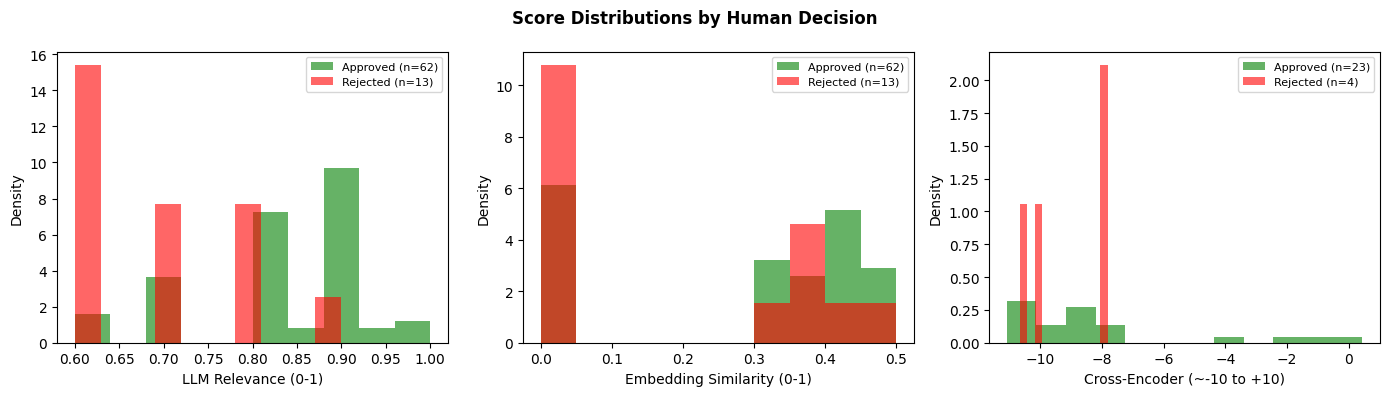

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

score_configs = [
    ("relevance", "LLM Relevance (0-1)", 10),
    ("embedding", "Embedding Similarity (0-1)", 10),
    ("cross_encoder", "Cross-Encoder (~-10 to +10)", 12),
]

for ax, (col, label, bins) in zip(axes, score_configs):
    # For cross-encoder, only include items that have scores
    mask = df[col] != 0.0 if col == "cross_encoder" else pd.Series(True, index=df.index)
    subset = df[mask]

    approved = subset[subset["approved"]][col]
    rejected = subset[~subset["approved"]][col]

    if len(approved) > 0:
        ax.hist(approved, bins=bins, alpha=0.6, color="green", label=f"Approved (n={len(approved)})", density=True)
    if len(rejected) > 0:
        ax.hist(rejected, bins=bins, alpha=0.6, color="red", label=f"Rejected (n={len(rejected)})", density=True)
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("Score Distributions by Human Decision", fontweight="bold")
plt.tight_layout()
plt.show()

## Per-Layer Baseline Accuracy

For each scoring layer independently: if we used **only** this score to auto-approve items, how well would it predict human decisions?

Prediction rule: `score >= threshold` -> predict approved.

In [4]:
def threshold_sweep(data, score_col, thresholds):
    """Compute precision, recall, F1, and counts at each threshold.

    Positive class = approved.
    Prediction: score >= threshold -> predict approved.
    """
    total_approved = data["approved"].sum()
    rows = []
    for t in thresholds:
        predicted_pos = data[data[score_col] >= t]
        n_predicted = len(predicted_pos)
        true_pos = predicted_pos["approved"].sum()

        precision = true_pos / n_predicted if n_predicted > 0 else 0
        recall = true_pos / total_approved if total_approved > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        rows.append({
            "threshold": t,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "predicted_approve": n_predicted,
            "true_positives": int(true_pos),
            "false_positives": n_predicted - int(true_pos),
        })
    return pd.DataFrame(rows)

In [5]:
# Use full dataset for relevance and embedding; filtered for cross-encoder
df_ce = df[df["cross_encoder"] != 0.0].copy()

sweeps = {
    "LLM Relevance": threshold_sweep(df, "relevance", np.arange(0.50, 1.01, 0.05)),
    "Embedding": threshold_sweep(df, "embedding", np.arange(0.10, 0.81, 0.05)),
    "Cross-Encoder": threshold_sweep(df_ce, "cross_encoder", np.arange(-5.0, 8.5, 0.5)),
}

for name, sweep_df in sweeps.items():
    best = sweep_df.loc[sweep_df["f1"].idxmax()]
    n_items = len(df_ce) if name == "Cross-Encoder" else len(df)
    print(f"\n{'=' * 65}")
    print(f"{name} (n={n_items})")
    print(f"  Best F1 = {best['f1']:.2f} at threshold {best['threshold']:.2f}")
    print(f"  Precision: {best['precision']:.0%} | Recall: {best['recall']:.0%}")
    print(f"  Would auto-approve {int(best['predicted_approve'])} of {n_items} items")
    print(f"{'=' * 65}")

    display(sweep_df.style.format({
        "threshold": "{:.2f}",
        "precision": "{:.0%}",
        "recall": "{:.0%}",
        "f1": "{:.2f}",
    }).highlight_max(subset=["f1"], color="lightgreen"))


LLM Relevance (n=75)
  Best F1 = 0.91 at threshold 0.60
  Precision: 89% | Recall: 94%
  Would auto-approve 65 of 75 items


,threshold,precision,recall,f1,predicted_approve,true_positives,false_positives
0,0.50,83%,100%,0.91,75,62,13
1,0.55,83%,100%,0.91,75,62,13
2,0.60,89%,94%,0.91,65,58,7
3,0.65,89%,94%,0.91,65,58,7
4,0.70,92%,79%,0.85,53,49,4
5,0.75,92%,79%,0.85,53,49,4
6,0.80,97%,50%,0.66,32,31,1
7,0.85,97%,47%,0.63,30,29,1
8,0.90,100%,8%,0.15,5,5,0
9,0.95,100%,5%,0.09,3,3,0



Embedding (n=75)
  Best F1 = 0.77 at threshold 0.10
  Precision: 88% | Recall: 69%
  Would auto-approve 49 of 75 items


,threshold,precision,recall,f1,predicted_approve,true_positives,false_positives
0,0.10,88%,69%,0.77,49,43,6
1,0.15,88%,69%,0.77,49,43,6
2,0.20,88%,69%,0.77,49,43,6
3,0.25,88%,69%,0.77,49,43,6
4,0.30,88%,69%,0.77,49,43,6
5,0.35,87%,53%,0.66,38,33,5
6,0.40,96%,37%,0.53,24,23,1
7,0.45,89%,13%,0.23,9,8,1
8,0.50,0%,0%,0.00,0,0,0
9,0.55,0%,0%,0.00,0,0,0



Cross-Encoder (n=27)
  Best F1 = 0.30 at threshold -5.00
  Precision: 100% | Recall: 17%
  Would auto-approve 4 of 27 items


,threshold,precision,recall,f1,predicted_approve,true_positives,false_positives
0,-5.00,100%,17%,0.30,4,4,0
1,-4.50,100%,17%,0.30,4,4,0
2,-4.00,100%,17%,0.30,4,4,0
3,-3.50,100%,17%,0.30,4,4,0
4,-3.00,100%,13%,0.23,3,3,0
5,-2.50,100%,13%,0.23,3,3,0
6,-2.00,100%,9%,0.16,2,2,0
7,-1.50,100%,9%,0.16,2,2,0
8,-1.00,100%,4%,0.08,1,1,0
9,-0.50,100%,4%,0.08,1,1,0


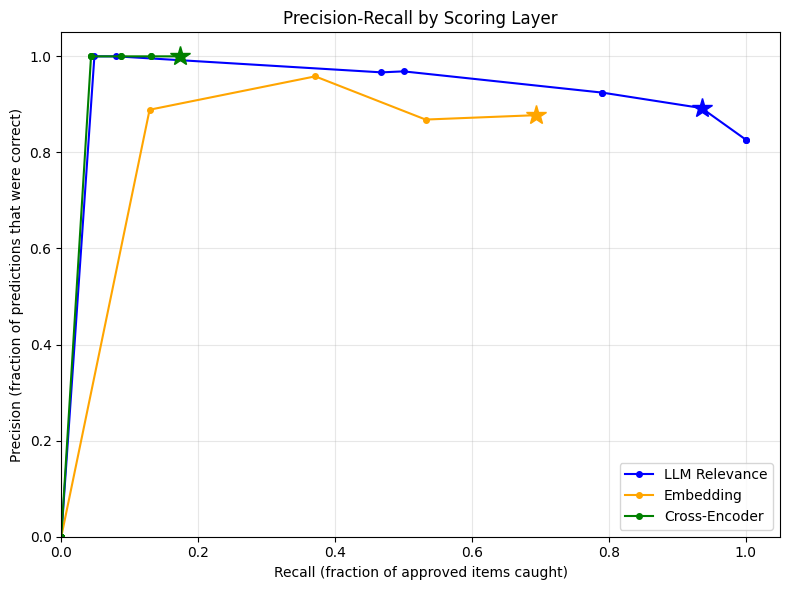

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {"LLM Relevance": "blue", "Embedding": "orange", "Cross-Encoder": "green"}

for name, sweep_df in sweeps.items():
    s = sweep_df.sort_values("recall")
    ax.plot(s["recall"], s["precision"], "o-", label=name, color=colors[name], markersize=4)
    # Mark the F1-optimal point with a star
    best = sweep_df.loc[sweep_df["f1"].idxmax()]
    ax.plot(best["recall"], best["precision"], "*", color=colors[name], markersize=15)

ax.set_xlabel("Recall (fraction of approved items caught)")
ax.set_ylabel("Precision (fraction of predictions that were correct)")
ax.set_title("Precision-Recall by Scoring Layer")
ax.legend()
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Layer Agreement & Correlation

Do the three scoring layers agree? Are any redundant? Which one best predicts human decisions?

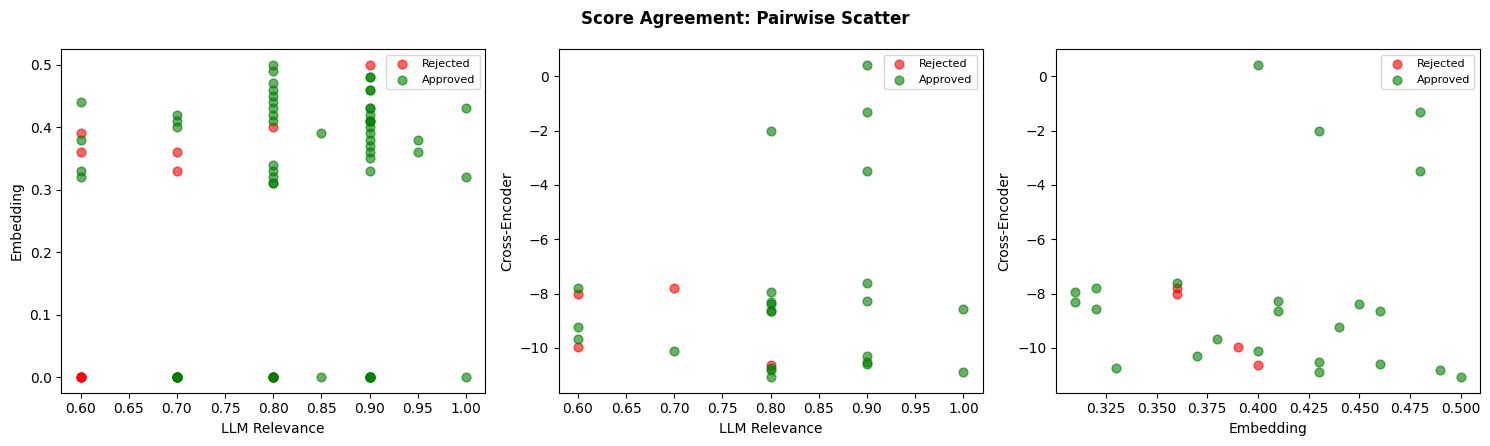

In [7]:
pairs = [
    ("relevance", "embedding", "LLM Relevance", "Embedding"),
    ("relevance", "cross_encoder", "LLM Relevance", "Cross-Encoder"),
    ("embedding", "cross_encoder", "Embedding", "Cross-Encoder"),
]

# Use only items with cross-encoder scores for the plots involving cross-encoder
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (x_col, y_col, x_label, y_label) in zip(axes, pairs):
    subset = df_ce if "cross_encoder" in (x_col, y_col) else df
    approved = subset[subset["approved"]]
    rejected = subset[~subset["approved"]]
    ax.scatter(rejected[x_col], rejected[y_col], c="red", alpha=0.6, label="Rejected", s=40, zorder=2)
    ax.scatter(approved[x_col], approved[y_col], c="green", alpha=0.6, label="Approved", s=40, zorder=3)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.legend(fontsize=8)

fig.suptitle("Score Agreement: Pairwise Scatter", fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
score_cols = ["relevance", "embedding", "cross_encoder", "approved"]

# Pearson — use only items with cross-encoder scores for a fair comparison
print(f"Pearson correlation (n={len(df_ce)} items with cross-encoder scores):")
display(
    df_ce[score_cols].corr()
    .style.format("{:.2f}")
    .background_gradient(cmap="RdYlGn", vmin=-1, vmax=1)
)

print(f"\nSpearman rank correlation (n={len(df_ce)}):")
display(
    df_ce[score_cols].corr(method="spearman")
    .style.format("{:.2f}")
    .background_gradient(cmap="RdYlGn", vmin=-1, vmax=1)
)

# Also show correlation on the full dataset (without cross-encoder)
print(f"\nPearson correlation — full dataset (n={len(df)}, relevance + embedding only):")
display(
    df[["relevance", "embedding", "approved"]].corr()
    .style.format("{:.2f}")
    .background_gradient(cmap="RdYlGn", vmin=-1, vmax=1)
)

Pearson correlation (n=27 items with cross-encoder scores):


,relevance,embedding,cross_encoder,approved
relevance,1.00,0.19,0.17,0.44
embedding,0.19,1.00,0.10,0.19
cross_encoder,0.17,0.10,1.00,0.13
approved,0.44,0.19,0.13,1.00



Spearman rank correlation (n=27):


,relevance,embedding,cross_encoder,approved
relevance,1.00,0.21,0.02,0.43
embedding,0.21,1.00,-0.23,0.24
cross_encoder,0.02,-0.23,1.00,0.01
approved,0.43,0.24,0.01,1.00



Pearson correlation — full dataset (n=75, relevance + embedding only):


,relevance,embedding,approved
relevance,1.00,0.19,0.46
embedding,0.19,1.00,0.19
approved,0.46,0.19,1.00


## Per-Source Breakdown

Are some sources consistently approved or rejected? Do certain sources have systematically different score distributions?

In [9]:
source_stats = (
    df.groupby("source")
    .agg(
        count=("approved", "size"),
        approved=("approved", "sum"),
        rate=("approved", "mean"),
        avg_relevance=("relevance", "mean"),
        avg_embedding=("embedding", "mean"),
        avg_cross_encoder=("cross_encoder", "mean"),
    )
    .sort_values("count", ascending=False)
)

display(source_stats.style.format({
    "approved": "{:.0f}",
    "rate": "{:.0%}",
    "avg_relevance": "{:.2f}",
    "avg_embedding": "{:.2f}",
    "avg_cross_encoder": "{:.1f}",
}))

,count,approved,rate,avg_relevance,avg_embedding,avg_cross_encoder
source,,,,,,
arXiv cs.AI,14,13,93%,0.84,0.14,0.0
Anthropic Blog,11,10,91%,0.78,0.25,-2.4
HuggingFace Blog,11,7,64%,0.80,0.23,-2.7
Simon Willison,11,8,73%,0.82,0.43,-7.1
Hacker News Top,10,8,80%,0.81,0.22,-1.9
arXiv cs.CL,5,4,80%,0.76,0.38,-3.2
Meta AI Blog,4,4,100%,0.70,0.42,-6.4
LangChain Blog,3,3,100%,0.90,0.26,-3.5
Mistral AI Blog,3,3,100%,0.90,0.34,-5.6


## Failure Modes

The interesting cases: where did the scoring system get it wrong?

- **False positives** — High scores, but you rejected it. Why?
- **False negatives** — Low scores, but you approved it. What did the system miss?
- **Disagreements** — The three layers gave conflicting signals. Which one was right?

In [10]:
# False positives: high-scoring items you rejected
rejected = df[~df["approved"]].copy()

print(f"Total rejected: {len(rejected)}")
print(f"\nHighest-scoring rejected items (the system would have auto-approved these):\n")
display(
    rejected
    .sort_values("relevance", ascending=False)
    .head(10)[["title", "source", "relevance", "embedding", "cross_encoder"]]
    .style.format({"relevance": "{:.2f}", "embedding": "{:.2f}", "cross_encoder": "{:.1f}"})
)

Total rejected: 13

Highest-scoring rejected items (the system would have auto-approved these):



,title,source,relevance,embedding,cross_encoder
33,Latest from Simon Willison,Simon Willison,0.90,0.50,0.0
12,"How I Trained Action Chunking Transformer (ACT) on SO-101: My Journey, Gotchas, and Lessons",HuggingFace Blog,0.80,0.40,-10.7
57,Mamba-3,Hacker News Top,0.80,0.00,0.0
60,Introducing SPEED-Bench: A Unified and Diverse Benchmark for Speculative Decoding,HuggingFace Blog,0.80,0.00,0.0
23,Streaming experts for Mixture-of-Experts models,Simon Willison,0.70,0.36,-7.8
39,Raw Robot Video to VLA-Ready Training Data: Annotating LeRobot Datasets with Nomadic and HuggingFace Buckets,HuggingFace Blog,0.70,0.33,0.0
54,POLARIS: Typed Planning and Governed Execution for Agentic AI in Back-Office Automation,arXiv cs.AI,0.70,0.00,0.0
16,New release of the base LLM plugin for Datasette,Simon Willison,0.60,0.39,-10.0
22,AR-RAG: Autoregressive Retrieval Augmentation for Image Generation,arXiv cs.CL,0.60,0.36,-8.0
30,"Shape, Symmetries, and Structure: The Changing Role of Mathematics in Machine Learning Research",The Gradient,0.60,0.00,0.0


In [11]:
# False negatives: low-scoring items you approved
approved_items = df[df["approved"]].copy()

print(f"Total approved: {len(approved_items)}")
print(f"\nLowest-scoring approved items (the system almost missed these):\n")
display(
    approved_items
    .sort_values("relevance", ascending=True)
    .head(10)[["title", "source", "relevance", "embedding", "cross_encoder"]]
    .style.format({"relevance": "{:.2f}", "embedding": "{:.2f}", "cross_encoder": "{:.1f}"})
)

Total approved: 62

Lowest-scoring approved items (the system almost missed these):



,title,source,relevance,embedding,cross_encoder
49,Anthropic invests $100 million into the Claude Partner Network,Anthropic Blog,0.60,0.33,0.0
19,TRIBE v2 reliably predicts high-resolution fMRI brain activity,Meta AI Blog,0.60,0.32,-7.8
26,Claude on Mars,Anthropic Blog,0.60,0.38,-9.7
25,Advanced AI models for emergency response automation,Meta AI Blog,0.60,0.44,-9.2
69,Caging the Agents: A Zero Trust Security Architecture for Autonomous AI in Healthcare,arXiv cs.AI,0.70,0.00,0.0
38,Hypura – A storage-tier-aware LLM inference scheduler for Apple Silicon,Hacker News Top,0.70,0.41,0.0
2,New Python Tool for Scanning Secrets in Directories,Simon Willison,0.70,0.40,-10.1
62,Anthropic invests $100 million into the Claude Partner Network,Anthropic Blog,0.70,0.00,0.0
31,AGI Is Not Multimodal,The Gradient,0.70,0.00,0.0
29,Intelligent Interaction Strategies for Context-Aware Cognitive Augmentation,arXiv cs.CL,0.70,0.42,0.0


In [12]:
# Layer disagreement analysis
# Use F1-optimal thresholds from sweep to define each layer's "approve" decision
best_thresholds = {}
for name, sweep_df in sweeps.items():
    best = sweep_df.loc[sweep_df["f1"].idxmax()]
    col = {"LLM Relevance": "relevance", "Embedding": "embedding", "Cross-Encoder": "cross_encoder"}[name]
    best_thresholds[col] = best["threshold"]

print("F1-optimal thresholds:", {k: f"{v:.2f}" for k, v in best_thresholds.items()})

# Count how many layers would approve each item (use df_ce for fair comparison)
df_ce = df_ce.copy()
df_ce["layers_approve"] = (
    (df_ce["relevance"] >= best_thresholds["relevance"]).astype(int)
    + (df_ce["embedding"] >= best_thresholds["embedding"]).astype(int)
    + (df_ce["cross_encoder"] >= best_thresholds["cross_encoder"]).astype(int)
)

all_agree = df_ce[df_ce["layers_approve"].isin([0, 3])]
disagreements = df_ce[df_ce["layers_approve"].isin([1, 2])]

print(f"\nAll 3 layers agree: {len(all_agree)} of {len(df_ce)} ({len(all_agree)/len(df_ce):.0%})")
print(f"Disagreement cases: {len(disagreements)} of {len(df_ce)} ({len(disagreements)/len(df_ce):.0%})")
print(f"  Approved in reality: {int(disagreements['approved'].sum())}")
print(f"  Rejected in reality: {int((~disagreements['approved']).sum())}")

if len(disagreements) > 0:
    print(f"\nDisagreement cases (sorted by # layers approving):\n")
    display(
        disagreements
        .sort_values(["layers_approve", "relevance"], ascending=[True, False])
        [["title", "source", "relevance", "embedding", "cross_encoder", "approved", "layers_approve"]]
        .style.format({"relevance": "{:.2f}", "embedding": "{:.2f}", "cross_encoder": "{:.1f}"})
    )

F1-optimal thresholds: {'relevance': '0.60', 'embedding': '0.10', 'cross_encoder': '-5.00'}

All 3 layers agree: 4 of 27 (15%)
Disagreement cases: 23 of 27 (85%)
  Approved in reality: 19
  Rejected in reality: 4

Disagreement cases (sorted by # layers approving):



,title,source,relevance,embedding,cross_encoder,approved,layers_approve
16,New release of the base LLM plugin for Datasette,Simon Willison,0.60,0.39,-10.0,False,1
19,TRIBE v2 reliably predicts high-resolution fMRI brain activity,Meta AI Blog,0.60,0.32,-7.8,True,1
22,AR-RAG: Autoregressive Retrieval Augmentation for Image Generation,arXiv cs.CL,0.60,0.36,-8.0,False,1
25,Advanced AI models for emergency response automation,Meta AI Blog,0.60,0.44,-9.2,True,1
26,Claude on Mars,Anthropic Blog,0.60,0.38,-9.7,True,1
0,Gemma 4: Google DeepMind Releases Open-Source Vision-Capable LLMs,Simon Willison,1.00,0.43,-10.9,True,2
9,"Voxtral TTS: A frontier, open-weights text-to-speech model that’s fast, instantly adaptable, and produces lifelike speech for voice agents",Mistral AI Blog,1.00,0.32,-8.6,True,2
3,Speculative Decoding in Practice: How EAGLE3 Makes LLMs Faster Without Changing Their Outputs,HuggingFace Blog,0.90,0.37,-10.3,True,2
6,Gemma 4: Open Vision- and Audio-Capable LLMs,Simon Willison,0.90,0.46,-10.6,True,2
11,Claude Code Found a Linux Vulnerability Hidden for 23 Years,Hacker News Top,0.90,0.36,-7.6,True,2


## Weekly Trend

Is the pipeline getting better over time as SCMS memory grows and the few-shot calibration kicks in?

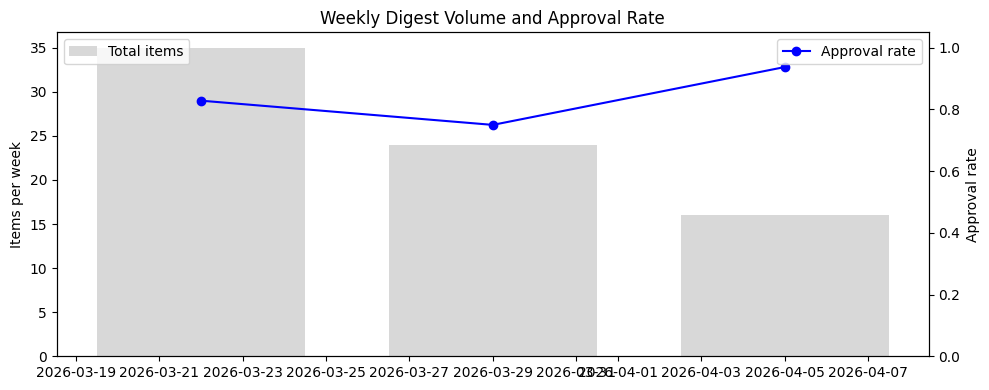

In [13]:
weekly = (
    df.set_index("created_at")
    .resample("W")
    .agg(total=("approved", "size"), n_approved=("approved", "sum"))
)
weekly["rate"] = weekly["n_approved"] / weekly["total"]
weekly = weekly[weekly["total"] > 0]

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.bar(weekly.index, weekly["total"], width=5, alpha=0.3, color="gray", label="Total items")
ax1.set_ylabel("Items per week")

ax2 = ax1.twinx()
ax2.plot(weekly.index, weekly["rate"], "o-", color="blue", label="Approval rate")
ax2.set_ylabel("Approval rate")
ax2.set_ylim(0, 1.05)

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
ax1.set_title("Weekly Digest Volume and Approval Rate")
plt.tight_layout()
plt.show()

## Summary

In [14]:
print("=" * 65)
print("SPRINT 9 BASELINE SUMMARY")
print("=" * 65)

print(f"\nDataset: {len(df)} labeled items, {int(df['approved'].sum())} approved ({df['approved'].mean():.0%})")
print(f"Date range: {df['created_at'].min():%Y-%m-%d} to {df['created_at'].max():%Y-%m-%d}")
print(f"Cross-encoder coverage: {len(df_ce)} of {len(df)} items")

print(f"\n--- Per-Layer Best F1 ---")
for name, sweep_df in sweeps.items():
    best = sweep_df.loc[sweep_df["f1"].idxmax()]
    print(f"  {name}: F1={best['f1']:.2f} at threshold {best['threshold']:.2f} "
          f"(precision={best['precision']:.0%}, recall={best['recall']:.0%})")

# Correlation with approval
corr = df_ce[["relevance", "embedding", "cross_encoder", "approved"]].corr()["approved"].drop("approved")
best_predictor = corr.abs().idxmax()
print(f"\n--- Correlation with Human Approval ---")
for col in ["relevance", "embedding", "cross_encoder"]:
    marker = "  <-- best" if col == best_predictor else ""
    print(f"  {col}: r={corr[col]:.2f}{marker}")

# Agreement
print(f"\n--- Layer Agreement (n={len(df_ce)} with all 3 scores) ---")
print(f"  All 3 layers agree: {len(all_agree)} of {len(df_ce)} ({len(all_agree)/len(df_ce):.0%})")
print(f"  Disagreement cases: {len(disagreements)} ({len(disagreements)/len(df_ce):.0%})")

print(f"\n--- Key Findings ---")
print(f"  Baseline (approve everything): {df['approved'].mean():.0%} precision")
if len(df) < 50:
    print(f"  !! Only {len(df)} items — all numbers are preliminary estimates.")
print(f"  Best single predictor: {best_predictor}")
print(f"  Highest-precision layer: {max(sweeps.items(), key=lambda x: x[1].loc[x[1]['f1'].idxmax()]['precision'])[0]}")
print(f"  Highest-recall layer: {max(sweeps.items(), key=lambda x: x[1].loc[x[1]['f1'].idxmax()]['recall'])[0]}")

SPRINT 9 BASELINE SUMMARY

Dataset: 75 labeled items, 62 approved (83%)
Date range: 2026-03-21 to 2026-04-05
Cross-encoder coverage: 27 of 75 items

--- Per-Layer Best F1 ---
  LLM Relevance: F1=0.91 at threshold 0.60 (precision=89%, recall=94%)
  Embedding: F1=0.77 at threshold 0.10 (precision=88%, recall=69%)
  Cross-Encoder: F1=0.30 at threshold -5.00 (precision=100%, recall=17%)

--- Correlation with Human Approval ---
  relevance: r=0.44  <-- best
  embedding: r=0.19
  cross_encoder: r=0.13

--- Layer Agreement (n=27 with all 3 scores) ---
  All 3 layers agree: 4 of 27 (15%)
  Disagreement cases: 23 (85%)

--- Key Findings ---
  Baseline (approve everything): 83% precision
  Best single predictor: relevance
  Highest-precision layer: Cross-Encoder
  Highest-recall layer: LLM Relevance
